# Exploratory Data Analysis — PathMNIST Colorectal Histopathology

This notebook systematically explores the PathMNIST dataset to inform modelling decisions.

**Goals:**
- Characterise dataset size, splits, and class balance
- Visualise representative tissue patches per class
- Examine per-channel pixel intensity statistics
- Preview and justify the augmentation strategy
- Summarise key findings that motivate preprocessing choices

In [ ]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter
from medmnist import PathMNIST
from torchvision import transforms

from src.dataset import CLASS_NAMES, get_raw_dataset

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
print('Environment ready.')

## 1. Dataset Overview

In [2]:
train_ds, val_ds, test_ds = get_raw_dataset(data_dir='../data', image_size=224)

print('PathMNIST — dataset summary')
print('=' * 40)
print(f'Classes      : {len(CLASS_NAMES)}')
print(f'Image size   : 224 × 224 × 3 (RGB)')
print(f'Train        : {len(train_ds):>7,}')
print(f'Validation   : {len(val_ds):>7,}')
print(f'Test         : {len(test_ds):>7,}')
print(f'Total        : {len(train_ds)+len(val_ds)+len(test_ds):>7,}')
print()
for i, n in enumerate(CLASS_NAMES):
    print(f'  {i}: {n}')

PathMNIST — dataset summary
Classes      : 9
Image size   : 224 × 224 × 3 (RGB)
Train        :  89,996
Validation   :  10,004
Test         :   7,180
Total        : 107,180

  0: Adipose
  1: Background
  2: Debris
  3: Lymphocytes
  4: Mucus
  5: Smooth Muscle
  6: Normal Colon Mucosa
  7: Cancer-Associated Stroma
  8: Colorectal Adenocarcinoma Epithelium


## 2. Class Distribution

Understanding label balance is essential — severe imbalance can bias a model toward majority classes 
and inflate accuracy while degrading per-class recall.  We quantify and visualise the distribution 
across all three splits.

In [3]:
def count_labels(ds):
    counts = Counter()
    for _, lbl in ds:
        counts[lbl.item() if hasattr(lbl, 'item') else int(lbl)] += 1
    return counts

tr_c, va_c, te_c = count_labels(train_ds), count_labels(val_ds), count_labels(test_ds)

rows = []
for i, name in enumerate(CLASS_NAMES):
    rows.append({'Class': name, 'Train': tr_c[i], 'Val': va_c[i], 'Test': te_c[i]})

df = pd.DataFrame(rows)
df['Total'] = df['Train'] + df['Val'] + df['Test']
df['Train %'] = (df['Train'] / df['Train'].sum() * 100).round(1)
print(df.to_string(index=False))

# Imbalance check
max_cls = df.loc[df['Train'].idxmax(), 'Class']
min_cls = df.loc[df['Train'].idxmin(), 'Class']
ratio = df['Train'].max() / df['Train'].min()
print(f'\nMax/min class ratio (train): {ratio:.2f}× ({max_cls} vs {min_cls})')

                               Class  Train  Val  Test  Total  Train %
                             Adipose   9366 1041  1338  11745     10.4
                          Background   9509 1057   847  11413     10.6
                              Debris  10360 1152   339  11851     11.5
                         Lymphocytes  10401 1156   634  12191     11.6
                               Mucus   8006  890  1035   9931      8.9
                       Smooth Muscle  12182 1354   592  14128     13.5
                 Normal Colon Mucosa   7886  877   741   9504      8.8
            Cancer-Associated Stroma   9401 1045   421  10867     10.4
Colorectal Adenocarcinoma Epithelium  12885 1432  1233  15550     14.3

Max/min class ratio (train): 1.63× (Colorectal Adenocarcinoma Epithelium vs Normal Colon Mucosa)


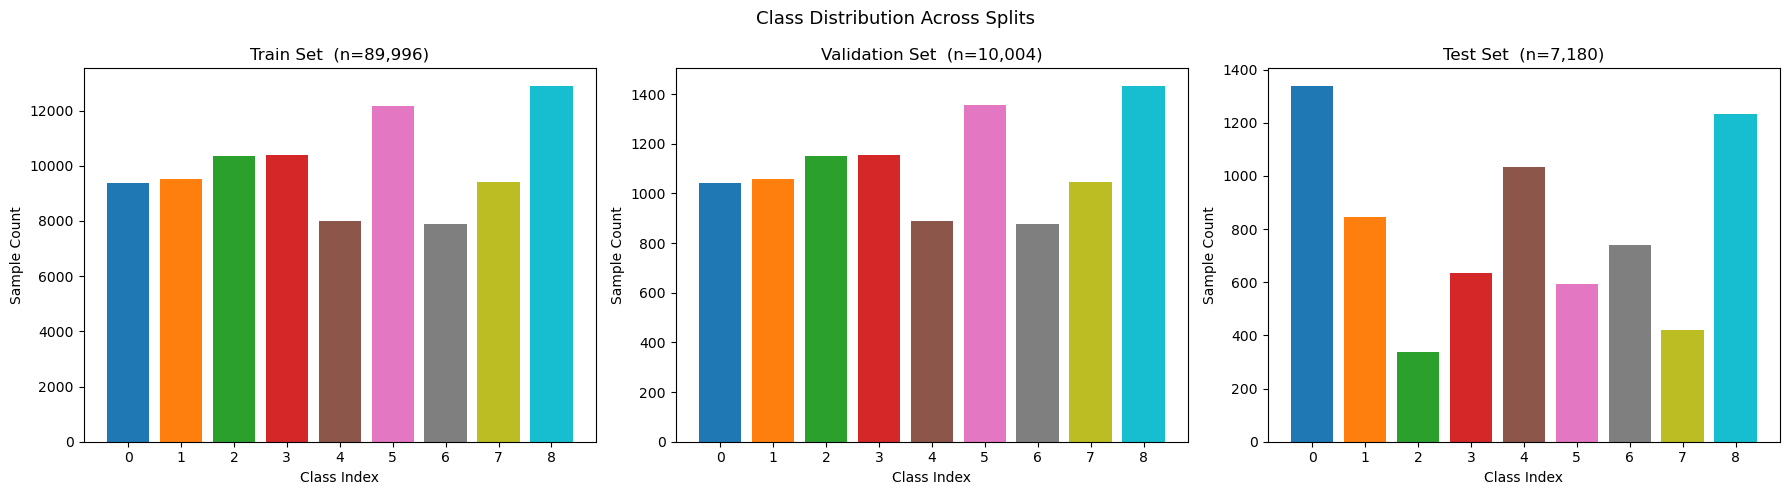


Class index legend:
  0: Adipose
  1: Background
  2: Debris
  3: Lymphocytes
  4: Mucus
  5: Smooth Muscle
  6: Normal Colon Mucosa
  7: Cancer-Associated Stroma
  8: Colorectal Adenocarcinoma Epithelium


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(CLASS_NAMES)))

for ax, (split, counts) in zip(axes, [('Train', tr_c), ('Validation', va_c), ('Test', te_c)]):
    vals = [counts[i] for i in range(len(CLASS_NAMES))]
    ax.bar(range(len(CLASS_NAMES)), vals, color=colors)
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels([str(i) for i in range(len(CLASS_NAMES))])
    ax.set_xlabel('Class Index')
    ax.set_ylabel('Sample Count')
    ax.set_title(f'{split} Set  (n={sum(vals):,})')

plt.suptitle('Class Distribution Across Splits', fontsize=13)
plt.tight_layout()
plt.savefig('../results/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClass index legend:')
for i, n in enumerate(CLASS_NAMES):
    print(f'  {i}: {n}')

**Observation**: The dataset shows mild class imbalance. The max/min ratio is well below 10×, 
so standard cross-entropy loss (with label smoothing) should suffice without explicit class weighting. 
We report weighted-average metrics to account for the imbalance in performance evaluation.

## 3. Representative Images per Class

Visual inspection confirms that tissue classes have distinct morphological signatures — 
e.g., adipose tissue shows clear circular vacuoles, while debris appears as amorphous eosinophilic staining.

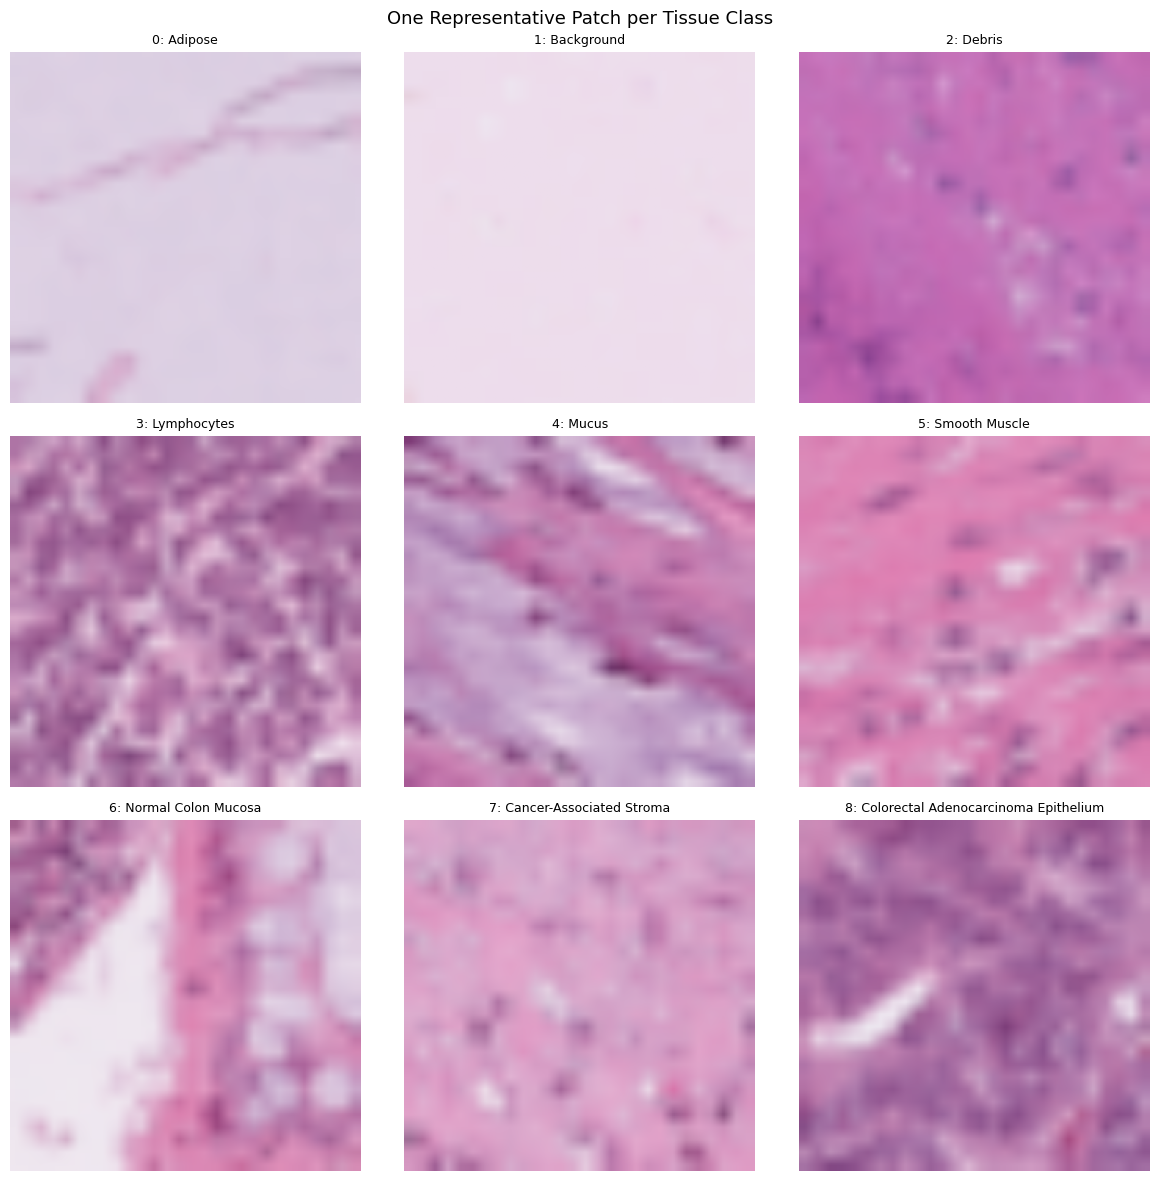

In [ ]:
class_samples = {i: None for i in range(len(CLASS_NAMES))}

for img, lbl in train_ds:
    c = lbl.item() if hasattr(lbl, 'item') else int(lbl)
    if class_samples[c] is None:
        class_samples[c] = img
    if all(v is not None for v in class_samples.values()):
        break

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    if i < len(CLASS_NAMES):
        ax.imshow(class_samples[i].permute(1, 2, 0).numpy())
        ax.set_title(f'{i}: {CLASS_NAMES[i]}', fontsize=9)
    ax.axis('off')

plt.suptitle('One Representative Patch per Tissue Class', fontsize=13)
plt.tight_layout()
plt.savefig('../results/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Per-Channel Pixel Intensity Analysis

H&E staining introduces systematic colour variation: haematoxylin (blue/purple) stains nuclei, 
while eosin (pink) stains cytoplasm and connective tissue.  Characterising per-channel statistics 
informs normalisation and colour augmentation choices.

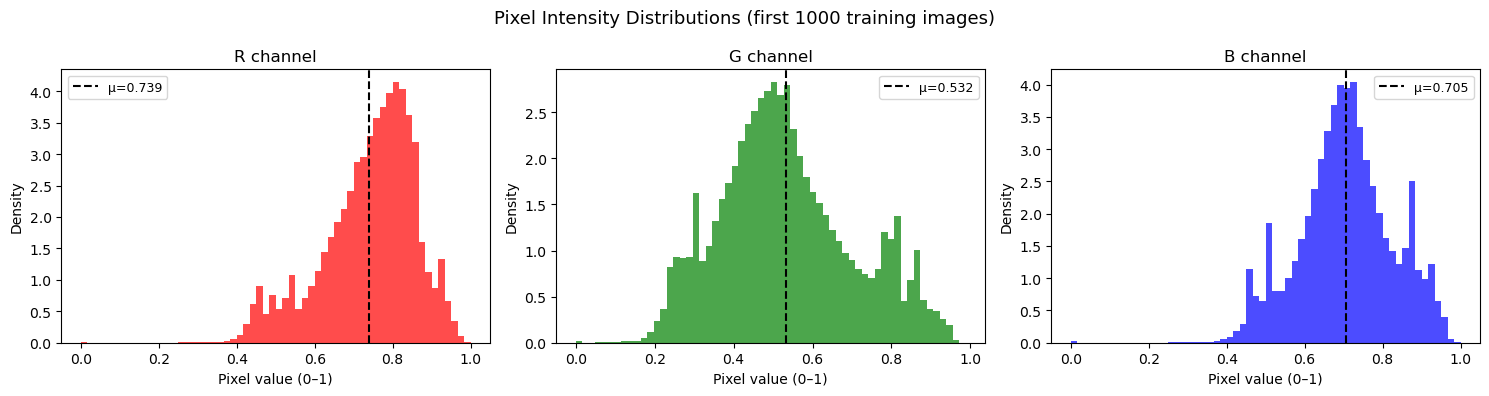

Channel statistics (normalised 0–1):
  R: mean=0.7393  std=0.1194  min=0.0000  max=0.9998
  G: mean=0.5325  std=0.1693  min=0.0000  max=0.9877
  B: mean=0.7048  std=0.1199  min=0.0000  max=1.0000


In [6]:
N = min(1000, len(train_ds))
channels = {'R': [], 'G': [], 'B': []}

for i in range(N):
    img, _ = train_ds[i]
    channels['R'].extend(img[0].numpy().flatten())
    channels['G'].extend(img[1].numpy().flatten())
    channels['B'].extend(img[2].numpy().flatten())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (ch, vals), col in zip(axes, channels.items(), ['red','green','blue']):
    vals = np.array(vals)
    ax.hist(vals, bins=60, color=col, alpha=0.7, density=True)
    ax.axvline(vals.mean(), color='black', ls='--', label=f'μ={vals.mean():.3f}')
    ax.set_title(f'{ch} channel')
    ax.set_xlabel('Pixel value (0–1)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle(f'Pixel Intensity Distributions (first {N} training images)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/pixel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Channel statistics (normalised 0–1):')
for ch, vals in channels.items():
    v = np.array(vals)
    print(f'  {ch}: mean={v.mean():.4f}  std={v.std():.4f}  min={v.min():.4f}  max={v.max():.4f}')

**Observation**: The R and G channels have higher mean intensities than B, consistent with the 
pink/purple hues of H&E-stained tissue.  The spread across channels justifies applying 
**colour jitter** augmentation to improve model robustness to staining variability across labs 
and slide preparation batches.

## 5. Augmentation Strategy Preview

Our training pipeline applies the following augmentations:
- **RandomHorizontalFlip / RandomVerticalFlip** (p=0.5): tissue orientation is arbitrary under the microscope
- **RandomRotation ±20°**: further orientation invariance
- **RandomPerspective** (p=0.3): simulates slight geometric distortion from scanning
- **ColorJitter** (brightness/contrast/saturation/hue): accounts for inter-lab staining variation
- **RandomGrayscale** (p=0.05): encourages reliance on texture rather than colour alone

100%|██████████| 12.6G/12.6G [10:53<00:00, 19.3MB/s]  


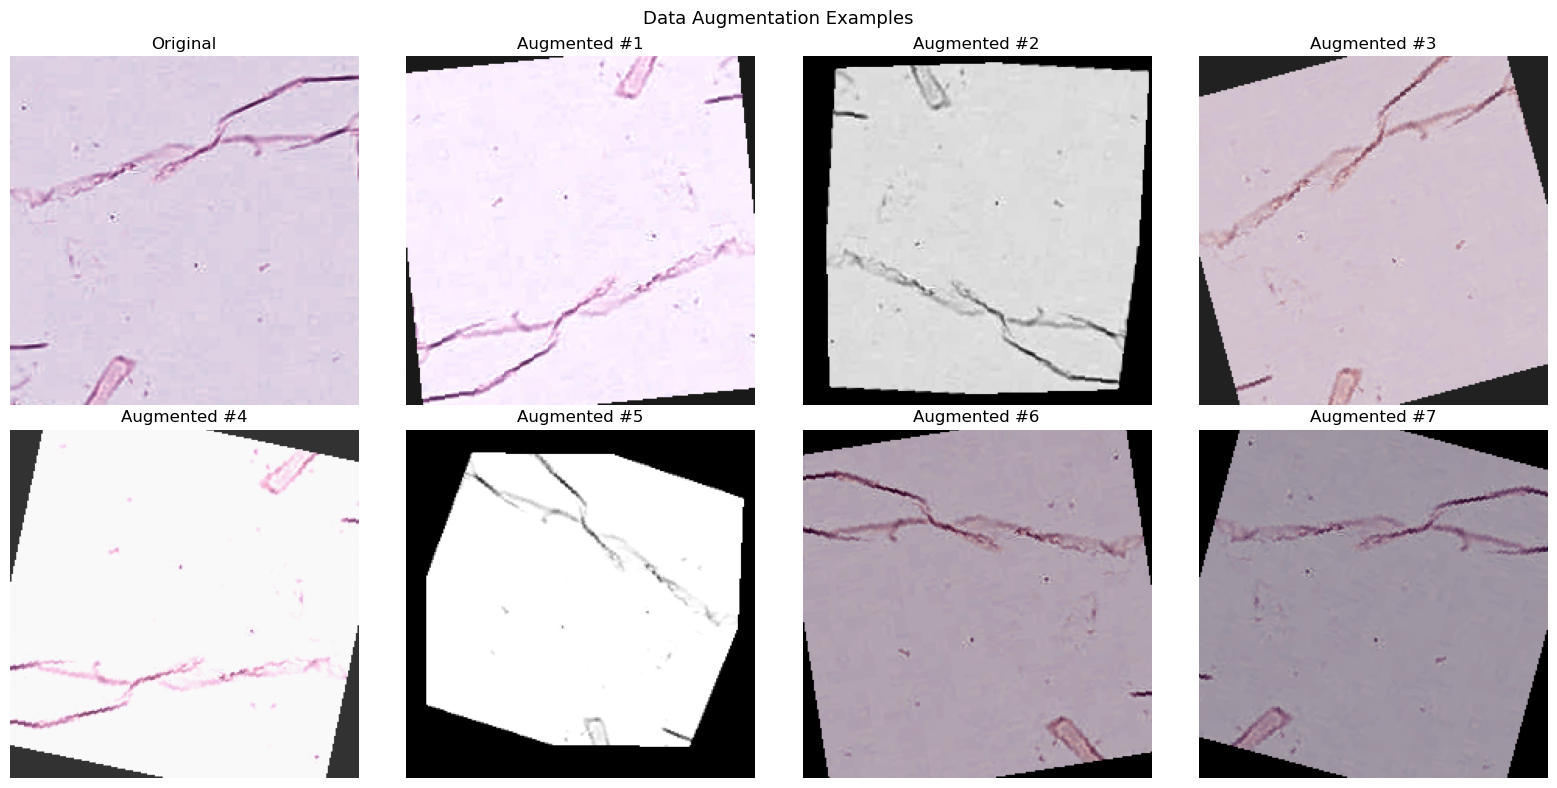

In [7]:
raw_transform = transforms.Compose([transforms.ToTensor()])
raw_ds = PathMNIST(split='train', transform=raw_transform, download=True, root='../data', size=224)

orig_tensor, _ = raw_ds[0]
orig_pil = transforms.ToPILImage()(orig_tensor)

aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.3),   # higher p so it shows in the preview
    transforms.ToTensor(),
])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes.flat[0].imshow(orig_pil)
axes.flat[0].set_title('Original')
axes.flat[0].axis('off')

for i, ax in enumerate(axes.flat[1:], 1):
    ax.imshow(aug(orig_pil).permute(1, 2, 0).numpy())
    ax.set_title(f'Augmented #{i}')
    ax.axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=13)
plt.tight_layout()
plt.savefig('../results/augmentation_preview.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. EDA Summary

| Finding | Modelling Implication |
|---|---|
| Mild class imbalance (ratio < 10×) | Weighted-average metrics; label smoothing sufficient |
| Tissue patches lack canonical orientation | Flip + rotation augmentation |
| H&E staining causes inter-lab colour shifts | Colour jitter + random grayscale augmentation |
| Distinct visual texture per class | CNN feature learning viable; SE attention helps channel selection |
| Cancer-Associated Stroma ≈ Smooth Muscle visually | Expect higher confusion for these two classes |

These observations directly motivate our choice of augmentation strategy, evaluation metrics, 
and the SE-attention mechanism in the from-scratch architecture.